# 02 - Exploración de Especies Curadas

Análisis exploratorio del dataset de 94 megadepredadores vertebrados e invertebrados
extraído de la Paleobiology Database (PBDB) API v1.2, usando una lista curada de
especies icónicas que cubren desde el Cámbrico hasta el presente.

**Objetivo:** Descubrir patrones de dominancia, resiliencia y distribución
a través de 540 millones de años de historia depredadora.

**Fuente:** `data/processed/pbdb_clean.csv`

## 0. Carga de Datos

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

df = pd.read_csv('../data/processed/pbdb_clean.csv')
df['Duracion_Ma'] = df['Primera_aparicion'] - df['Ultima_aparicion']
print(f'Dataset: {df.shape[0]} especies - {df.shape[1]} columnas')

df.head()

Dataset: 94 especies - 8 columnas


,Nombre,Grupo,Clase,Primera_aparicion,Ultima_aparicion,Dieta,Entorno,Duracion_Ma
0,Anomalocaris canadensis,Radiodonta,Invertebrado,509.7,497.0,carnivore,marine,12.7
1,Peytoia nathorsti,Radiodonta,Invertebrado,509.7,497.0,carnivore,marine,12.7
2,Hurdia victoria,Radiodonta,Invertebrado,509.7,504.5,carnivore,marine,5.2
3,Timorebestia koprii,Chaetognatha,Invertebrado,521.0,516.0,carnivore,marine,5.0
4,Cameroceras trentonense,Nautiloidea,Invertebrado,457.3,449.6,carnivore,marine,7.7


## 1. Vista General

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nombre             94 non-null     object 
 1   Grupo              94 non-null     object 
 2   Clase              94 non-null     object 
 3   Primera_aparicion  94 non-null     float64
 4   Ultima_aparicion   94 non-null     float64
 5   Dieta              94 non-null     object 
 6   Entorno            94 non-null     object 
 7   Duracion_Ma        94 non-null     float64
dtypes: float64(3), object(5)
memory usage: 6.0+ KB


In [11]:
df.describe()

,Primera_aparicion,Ultima_aparicion,Duracion_Ma
count,94.000000,94.000000,94.000000
mean,162.541660,149.622167,12.919493
std,147.596983,147.231846,12.539569
min,1.750000,0.000000,0.910000
25%,48.070000,34.852500,5.230325
50%,119.570000,93.900000,8.860000
75%,256.307500,249.759000,15.850000
max,521.000000,516.000000,65.660000


## 2. ¿Qué grupo dominó más tiempo?

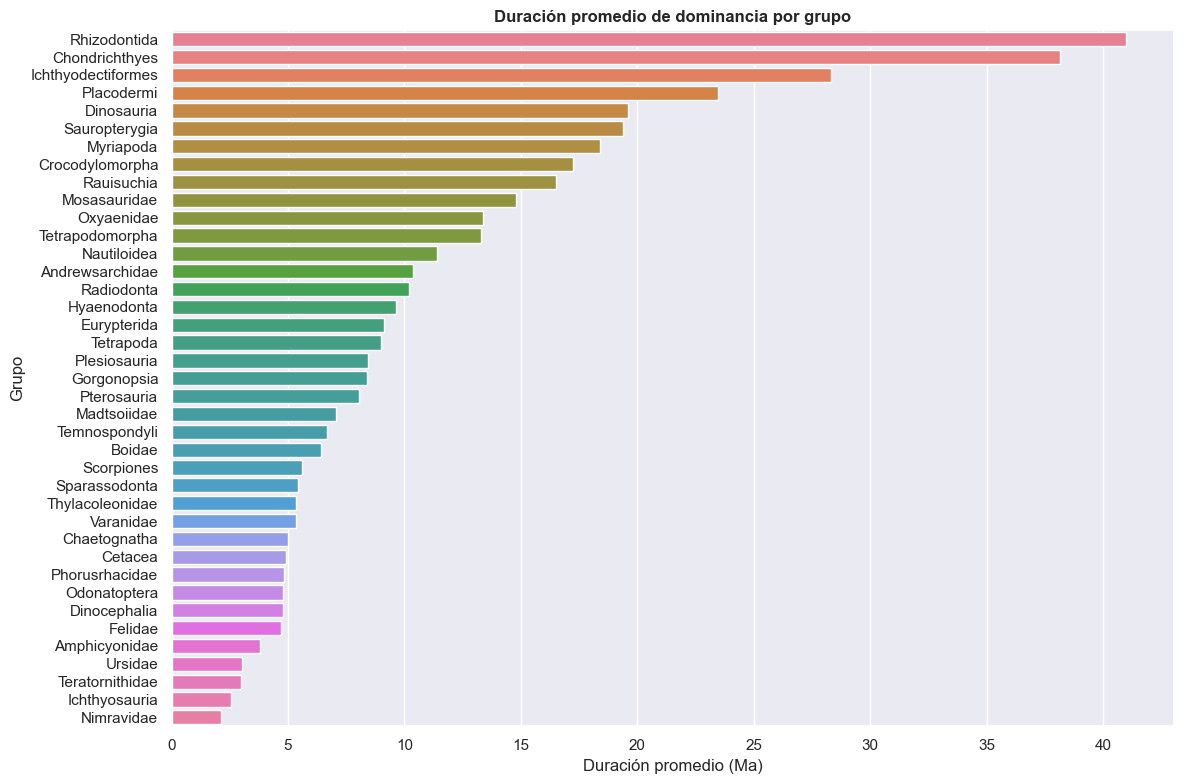

In [15]:
promedio_grupo = df.groupby('Grupo')['Duracion_Ma'].mean()
promedio_grupo = promedio_grupo.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(x=promedio_grupo.values, y=promedio_grupo.index, ax=ax, hue=promedio_grupo.index, legend=False)

ax.set_xlabel('Duración promedio (Ma)')
ax.set_title('Duración promedio de dominancia por grupo', fontweight='bold')
plt.tight_layout()
plt.show()

### Hallazgo
Los peces cartilaginosos (Chondrichthyes) y los peces de aletas lobuladas (Rhizodontida) 
dominaron más tiempo que los dinosaurios un resultado que contradice la intuición popular.
Los tiburones no son solo supervivientes modernos, son el linaje depredador más duradero de la historia.

## 3. ¿Qué período tuvo más depredadores simultáneos?

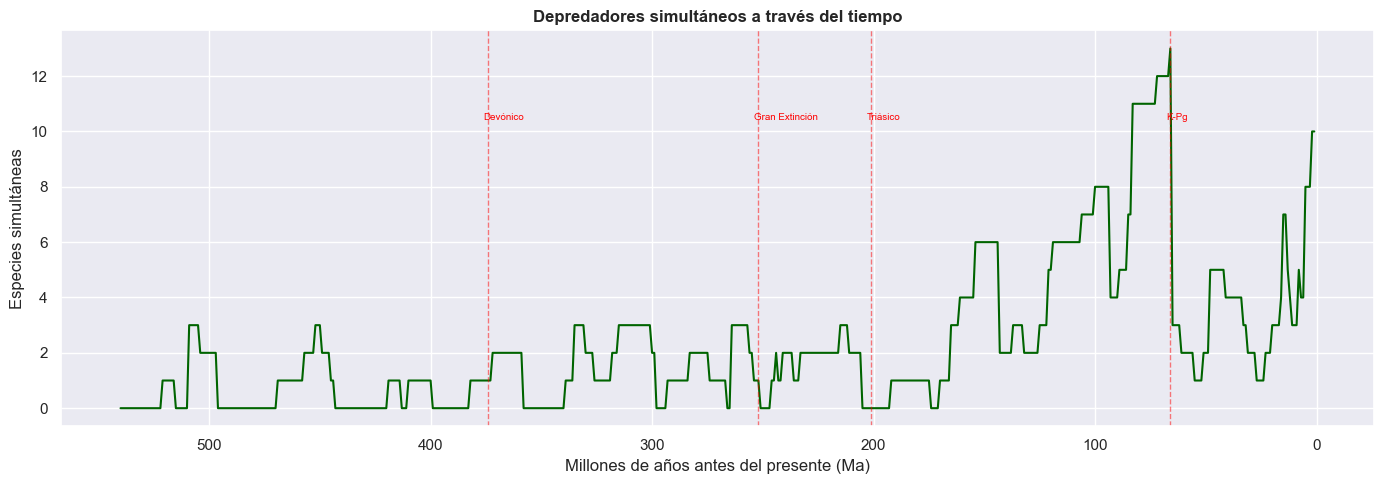

In [22]:
import numpy as np

tiempo = np.arange(540, 0, -1)
conteo = []

for t in tiempo:
    vivas = df[(df['Primera_aparicion'] >= t) & (df['Ultima_aparicion'] <= t)]
    conteo.append(len(vivas))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tiempo, conteo, color='darkgreen', linewidth=1.5)
ax.invert_xaxis()
ax.set_xlabel('Millones de años antes del presente (Ma)')
ax.set_ylabel('Especies simultáneas')
ax.set_title('Depredadores simultáneos a través del tiempo', fontweight='bold')

# Extinciones masivas
for ma, nombre in [(252, 'Gran Extinción'), (66, 'K-Pg'), (201, 'Triásico'), (374, 'Devónico')]:
    ax.axvline(ma, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(ma+2, max(conteo)*0.8, nombre, fontsize=7, color='red')

plt.tight_layout()
plt.show()

### Hallazgo
El Cretácico tardío fue el período más peligroso de la historia, hasta 13 megadepredadores
coexistieron simultáneamente. La extinción K-Pg no solo mató a los dinosaurios,
destruyó el ecosistema depredador más peligros que la Tierra habia conocido.

## 4. ¿Quién sobrevivió más extinciones masivas?

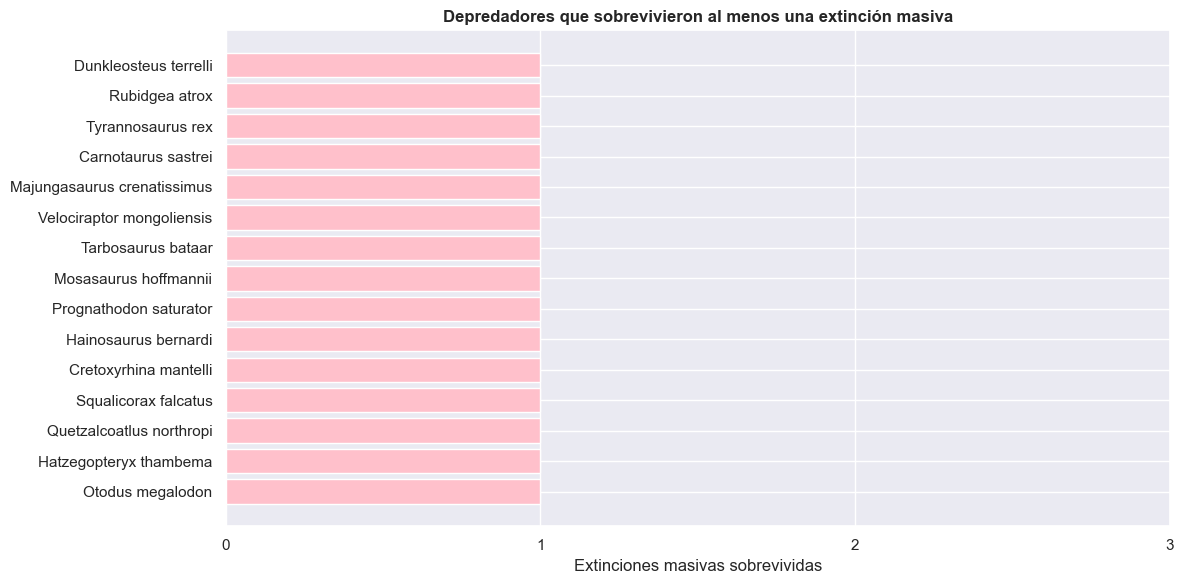

In [30]:
EXTINCIONES = [443, 374, 252, 201, 66]

def contar_extinciones(row):
    return sum(
        row['Ultima_aparicion'] <= ext <= row['Primera_aparicion']
        for ext in EXTINCIONES
    )

df['Extinciones_sobrevividas'] = df.apply(contar_extinciones, axis=1)

top = df[df['Extinciones_sobrevividas'] >= 1].sort_values('Extinciones_sobrevividas', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top['Nombre'], top['Extinciones_sobrevividas'], color='pink')
ax.set_xlabel('Extinciones masivas sobrevividas')
ax.set_title('Depredadores que sobrevivieron al menos una extinción masiva', fontweight='bold')
ax.set_xlim(0, 3)
ax.set_xticks([0, 1, 2, 3])
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Hallazgo
Ser el depredador más poderoso es también una durante una extinción masiva.
Ninguna especie de nuestra lista sobrevivió más de una extinción, los apex predators
son los primeros en desaparecer cuando el ecosistema colapsa.

## 5. ¿Marine vs Terrestre a través del tiempo?

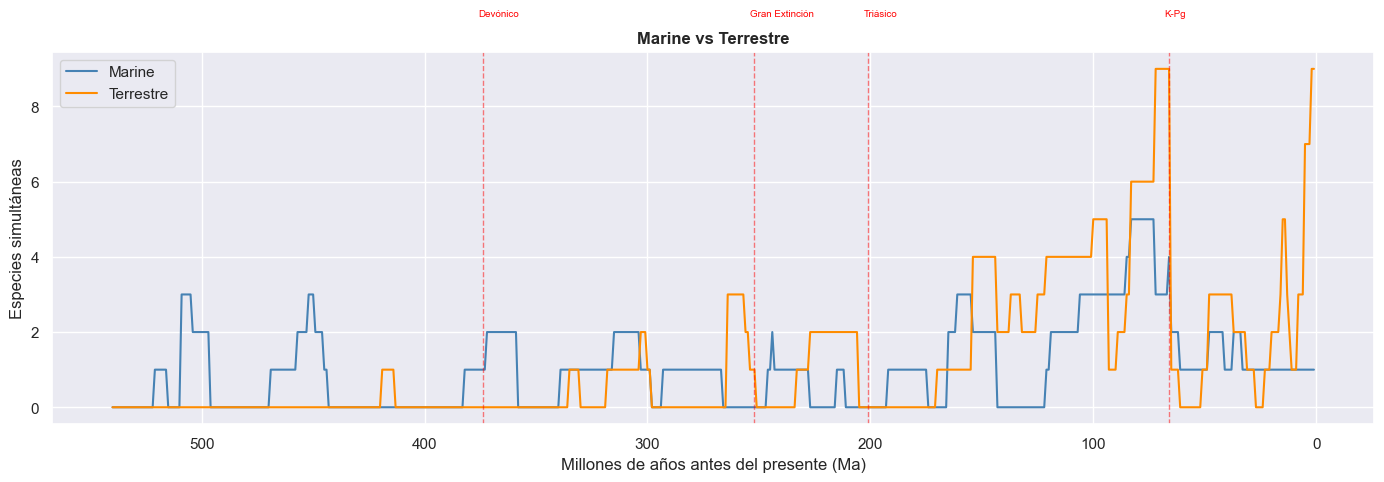

In [31]:
import numpy as np

tiempo = np.arange(540, 0, -1)
conteo = []
marinas = []
terrestre = []

for t in tiempo:
    vivas = df[(df['Primera_aparicion'] >= t) & (df['Ultima_aparicion'] <= t)]
    marinas.append(len(vivas[vivas['Entorno'] == 'marine']))
    terrestre.append(len(vivas[vivas['Entorno'] == 'terrestrial']))
    conteo.append(len(vivas))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tiempo, marinas, color='steelblue', linewidth=1.5, label='Marine')
ax.plot(tiempo, terrestre, color='darkorange', linewidth=1.5, label='Terrestre')
ax.legend()
ax.invert_xaxis()
ax.set_xlabel('Millones de años antes del presente (Ma)')
ax.set_ylabel('Especies simultáneas')
ax.set_title('Marine vs Terrestre', fontweight='bold')

# Extinciones masivas
for ma, nombre in [(252, 'Gran Extinción'), (66, 'K-Pg'), (201, 'Triásico'), (374, 'Devónico')]:
    ax.axvline(ma, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(ma+2, max(conteo)*0.8, nombre, fontsize=7, color='red')

plt.tight_layout()
plt.show()

### Hallazgo
El océano dominó durante 400 millones de años. Todo cambió hace 66 Ma cuando los dinosaurios
desaparecieron, los mamíferos terrestres tomaron el control de forma explosiva.

## 6. Los campeones individuales

In [36]:
print('El depredador con mayor duracion en la tierra:')
df.nlargest(1, 'Duracion_Ma')

El depredador con mayor duracion en la tierra:


,Nombre,Grupo,Clase,Primera_aparicion,Ultima_aparicion,Dieta,Entorno,Duracion_Ma,Extinciones_sobrevividas
74,Otodus megalodon,Chondrichthyes,Chondrichthyes,66.0,0.34,carnivore,marine,65.66,1


In [37]:
print('El depredador mas antiguo:')
df.nlargest(1, 'Primera_aparicion')

El depredador mas antiguo:


,Nombre,Grupo,Clase,Primera_aparicion,Ultima_aparicion,Dieta,Entorno,Duracion_Ma,Extinciones_sobrevividas
3,Timorebestia koprii,Chaetognatha,Invertebrado,521.0,516.0,carnivore,marine,5.0,0


In [39]:
print('El depredador mas recientes de los fosiles:')
df.nsmallest(1, 'Ultima_aparicion')

El depredador mas recientes de los fosiles:


,Nombre,Grupo,Clase,Primera_aparicion,Ultima_aparicion,Dieta,Entorno,Duracion_Ma,Extinciones_sobrevividas
84,Smilodon populator,Felidae,Mammalia,2.58,0.0,carnivore,terrestrial,2.58,0


### Hallazgo
- Mayor duración: Otodus megalodon - dominó los océanos por más de 20 millones de años
- Más antiguo: Timorebestia koprii - depredador del Cámbrico hace 521 Ma, casi nadie lo conoce
- Más reciente: Smilodon populator - se extinguió hace apenas 10,000 años, cuando los humanos ya construían las primeras ciudades